In [1]:
# ============================================================
# Notebook 02: Exploratory Data Analysis
# AI Financial Risk Intelligence Platform
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Project paths
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "german.data"

# Column names
column_names = [
    "status", "duration", "credit_history", "purpose", "credit_amount",
    "savings", "employment_duration", "installment_rate", "personal_status_sex",
    "other_debtors", "present_residence", "property", "age",
    "other_installment_plans", "housing", "existing_credits", "job",
    "people_liable", "telephone", "foreign_worker", "target"
]

# Load data
df = pd.read_csv(
    DATA_PATH,
    sep=r"\s+",
    header=None,
    names=column_names
)

# Convert target
df["target"] = df["target"].map({1: 0, 2: 1})

print("Dataset loaded successfully")
print(df.shape)

Dataset loaded successfully
(1000, 21)


In [2]:
# ============================================================
# Dataset Overview
# ============================================================

print(df.info())

print("\nSummary Statistics:")
display(df.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status                   1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   savings                  1000 non-null   object
 6   employment_duration      1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  present_residence        1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

,count,mean,std,min,25%,50%,75%,max
duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
credit_amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
installment_rate,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
present_residence,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0
age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
existing_credits,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0
people_liable,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0
target,1000.0,0.300,0.458487,0.0,0.0,0.0,1.00,1.0


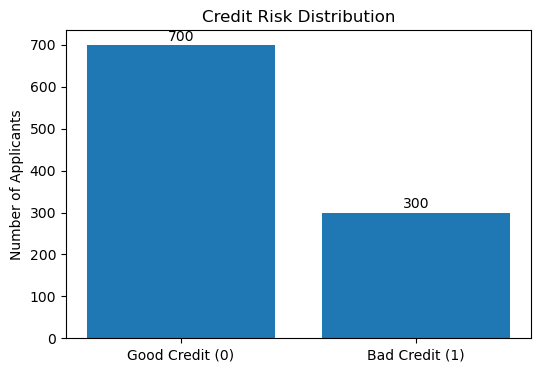

target
0    70.0
1    30.0
Name: count, dtype: float64


In [3]:
# ============================================================
# Target Distribution
# ============================================================

target_counts = df["target"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(
    ["Good Credit (0)", "Bad Credit (1)"],
    target_counts.values
)

plt.title("Credit Risk Distribution")
plt.ylabel("Number of Applicants")

for i, value in enumerate(target_counts.values):
    plt.text(i, value + 10, str(value), ha="center")

plt.show()

print((target_counts / len(df) * 100).round(2))

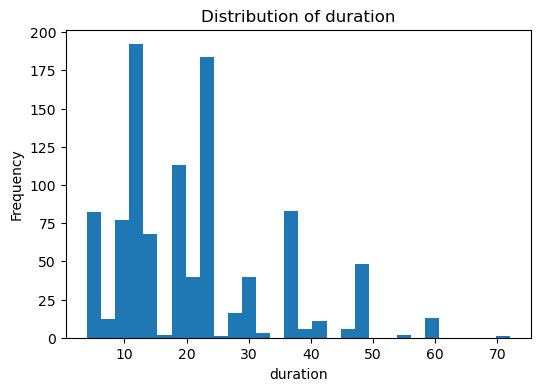

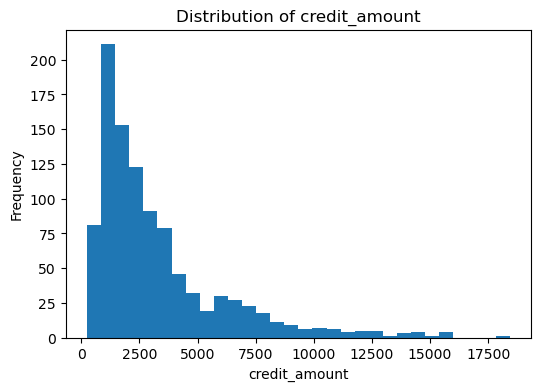

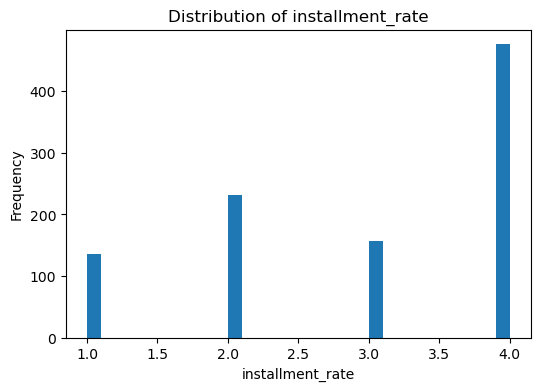

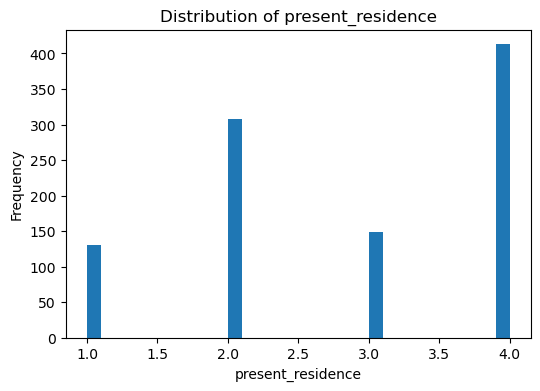

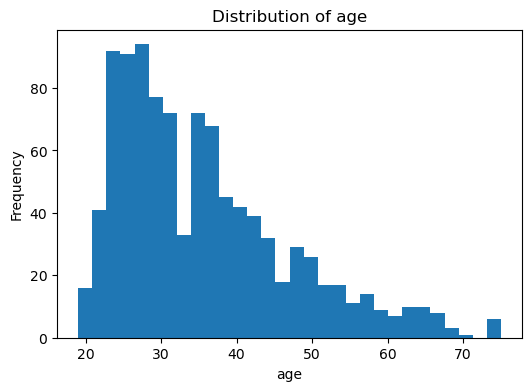

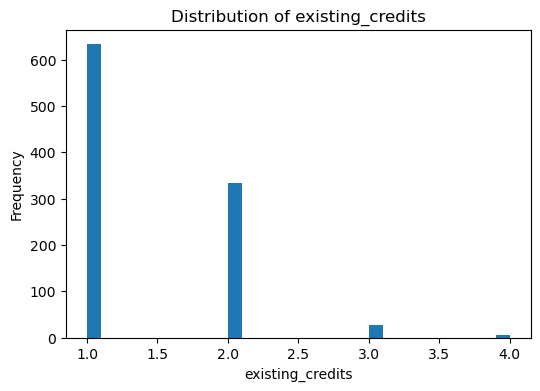

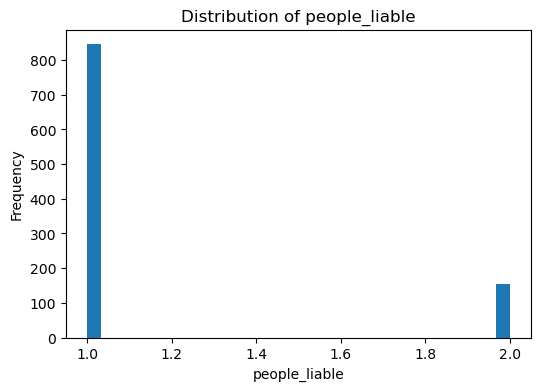

In [4]:
# ============================================================
# Numerical Feature Distributions
# ============================================================

numerical_cols = [
    "duration",
    "credit_amount",
    "installment_rate",
    "present_residence",
    "age",
    "existing_credits",
    "people_liable"
]

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [5]:
# ============================================================
# Numerical Feature Summary
# ============================================================

numerical_cols = [
    "duration",
    "credit_amount",
    "installment_rate",
    "present_residence",
    "age",
    "existing_credits",
    "people_liable"
]

summary = df[numerical_cols].describe().T

display(summary)

,count,mean,std,min,25%,50%,75%,max
duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
credit_amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
installment_rate,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
present_residence,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0
age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
existing_credits,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0
people_liable,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0


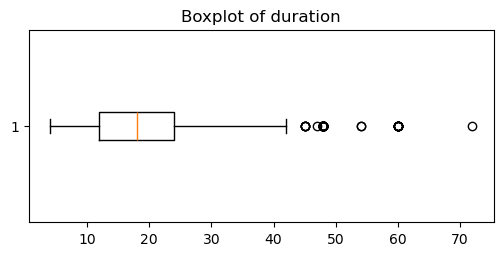

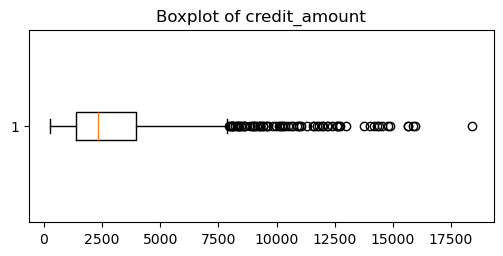

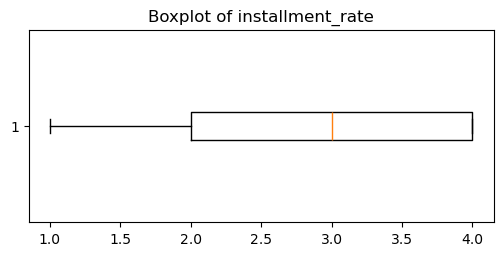

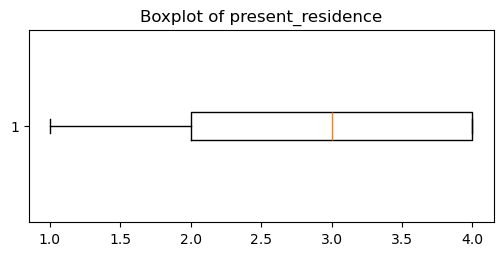

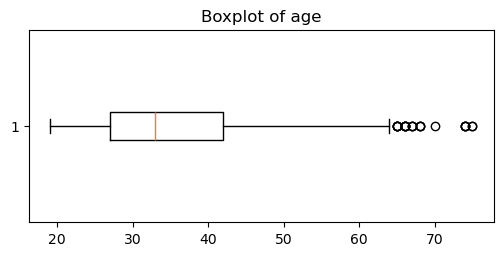

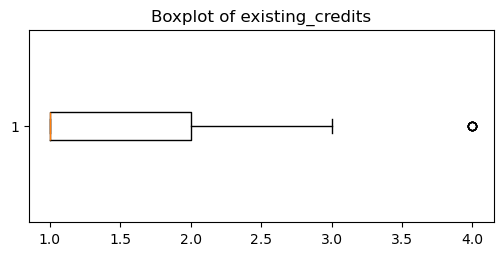

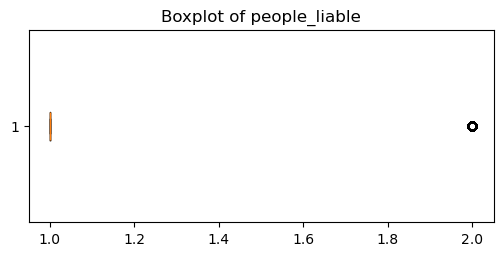

In [6]:
# ============================================================
# Boxplots for Numerical Features
# ============================================================

for col in numerical_cols:
    plt.figure(figsize=(6,2.5))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot of {col}")
    plt.show()

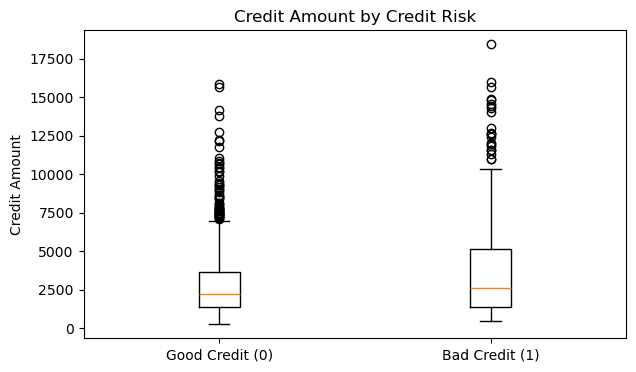

Good Credit Mean: 2985.46
Bad Credit Mean : 3938.13


In [7]:
# ============================================================
# Credit Amount by Target Class
# ============================================================

good_credit = df[df["target"] == 0]["credit_amount"]
bad_credit = df[df["target"] == 1]["credit_amount"]

plt.figure(figsize=(7,4))

plt.boxplot(
    [good_credit, bad_credit],
    tick_labels=["Good Credit (0)", "Bad Credit (1)"]
)

plt.title("Credit Amount by Credit Risk")
plt.ylabel("Credit Amount")

plt.show()

print("Good Credit Mean:", round(good_credit.mean(), 2))
print("Bad Credit Mean :", round(bad_credit.mean(), 2))

### Insight: Credit Amount and Credit Risk

The average credit amount for bad-credit customers (3938.13) is substantially higher than for good-credit customers (2985.46).

This suggests that applicants requesting larger loans may have a higher probability of default. The result indicates that **credit_amount** is likely to be an important predictive feature for the Logistic Regression model and should be retained during preprocessing and modeling.


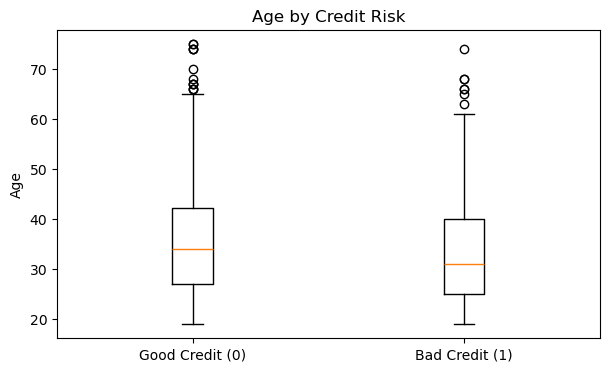

Good Credit Mean Age: 36.22
Bad Credit Mean Age : 33.96


In [8]:
# ============================================================
# Age by Credit Risk
# ============================================================

good_age = df[df["target"] == 0]["age"]
bad_age = df[df["target"] == 1]["age"]

plt.figure(figsize=(7,4))
plt.boxplot(
    [good_age, bad_age],
    tick_labels=["Good Credit (0)", "Bad Credit (1)"]
)

plt.title("Age by Credit Risk")
plt.ylabel("Age")
plt.show()

print("Good Credit Mean Age:", round(good_age.mean(), 2))
print("Bad Credit Mean Age :", round(bad_age.mean(), 2))

### Insight: Age and Credit Risk

The average age of good-credit customers (36.22) is slightly higher than that of bad-credit customers (33.96).

This suggests that older applicants may be somewhat less likely to default on their loans. Age is therefore a potentially useful predictive feature and may receive a negative coefficient in the Logistic Regression model, indicating that increasing age reduces the probability of bad credit.


In [9]:
# ============================================================
# Credit History vs Credit Risk
# ============================================================

credit_history_table = pd.crosstab(
    df["credit_history"],
    df["target"],
    normalize="index"
) * 100

display(credit_history_table.round(2))

target,0,1
credit_history,,
A30,37.50,62.50
A31,42.86,57.14
A32,68.11,31.89
A33,68.18,31.82
A34,82.94,17.06


### Insight: Credit History Is a Strong Risk Indicator

Credit history shows a clear relationship with default risk.

* **A30:** 62.5% bad credit
* **A31:** 57.1% bad credit
* **A34:** only 17.1% bad credit

Applicants with categories A30 and A31 are substantially riskier than those with A34, indicating that historical repayment behavior is likely one of the most important predictive features in the dataset.

This feature is expected to receive significant coefficients in the Logistic Regression model and should be retained during preprocessing and modeling.


In [10]:
# ============================================================
# Bad Credit Rate by Categorical Feature
# ============================================================

categorical_cols = [
    "status", "credit_history", "purpose", "savings",
    "employment_duration", "personal_status_sex",
    "other_debtors", "property",
    "other_installment_plans", "housing",
    "job", "telephone", "foreign_worker"
]

for col in categorical_cols:
    print("=" * 50)
    print(col)
    rates = (
        df.groupby(col)["target"]
          .mean()
          .sort_values(ascending=False)
          .round(3)
    )
    print(rates)
    print()

status
status
A11    0.493
A12    0.390
A13    0.222
A14    0.117
Name: target, dtype: float64

credit_history
credit_history
A30    0.625
A31    0.571
A32    0.319
A33    0.318
A34    0.171
Name: target, dtype: float64

purpose
purpose
A46     0.440
A410    0.417
A40     0.380
A45     0.364
A49     0.351
A44     0.333
A42     0.320
A43     0.221
A41     0.165
A48     0.111
Name: target, dtype: float64

savings
savings
A61    0.360
A62    0.330
A65    0.175
A63    0.175
A64    0.125
Name: target, dtype: float64

employment_duration
employment_duration
A72    0.407
A71    0.371
A73    0.307
A75    0.253
A74    0.224
Name: target, dtype: float64

personal_status_sex
personal_status_sex
A91    0.400
A92    0.352
A94    0.272
A93    0.266
Name: target, dtype: float64

other_debtors
other_debtors
A102    0.439
A101    0.300
A103    0.192
Name: target, dtype: float64

property
property
A124    0.435
A123    0.307
A122    0.306
A121    0.213
Name: target, dtype: float64

other_installment_pla

## Key EDA Insights

### Credit History

Credit history is the strongest categorical predictor observed during EDA.

* **A30:** 62.5% bad credit
* **A31:** 57.1% bad credit
* **A34:** 17.1% bad credit

This indicates a strong relationship between historical repayment behavior and default risk.

### Status

Applicant status also shows a significant risk gradient.

* **A11:** 49.3% bad credit
* **A14:** 11.7% bad credit

Applicants in category A11 appear substantially riskier than those in A14.

### Savings

Savings categories exhibit meaningful separation.

* **A61:** 36.0% bad credit
* **A64:** 12.5% bad credit

Lower savings levels appear associated with increased default risk.

### Numerical Features

* Bad-credit customers request **larger loans on average**.
* Good-credit customers are **slightly older on average**.

These observations suggest that **credit_history, status, savings, credit_amount, and age** are likely to become important predictors in the Logistic Regression model.


In [11]:
# ============================================================
# Correlation Matrix
# ============================================================

numerical_cols = [
    "duration",
    "credit_amount",
    "installment_rate",
    "present_residence",
    "age",
    "existing_credits",
    "people_liable"
]

corr = df[numerical_cols].corr()

display(corr.round(2))

,duration,credit_amount,installment_rate,present_residence,age,existing_credits,people_liable
duration,1.00,0.62,0.07,0.03,-0.04,-0.01,-0.02
credit_amount,0.62,1.00,-0.27,0.03,0.03,0.02,0.02
installment_rate,0.07,-0.27,1.00,0.05,0.06,0.02,-0.07
present_residence,0.03,0.03,0.05,1.00,0.27,0.09,0.04
age,-0.04,0.03,0.06,0.27,1.00,0.15,0.12
existing_credits,-0.01,0.02,0.02,0.09,0.15,1.00,0.11
people_liable,-0.02,0.02,-0.07,0.04,0.12,0.11,1.00


### Correlation Analysis

The strongest numerical correlation is between **duration** and **credit_amount** (0.62), indicating that larger loans are generally associated with longer repayment periods.

Most other numerical features exhibit relatively weak correlations, suggesting that they contribute largely independent information to the model.

Because the highest correlation is moderate rather than extreme, both features will be retained for the initial Logistic Regression baseline and multicollinearity will be monitored during model evaluation.
